In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [19]:
import os
import pandas as pd
from pathlib import Path

# ✅ FIXED: Correct folder name with space and proper capitalization
data_dir = Path("../data/raw/Garbage Classification")

categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# Verify the path exists before continuing
if not data_dir.exists():
    print(f"❌ data_dir not found: {data_dir.resolve()}")
    print(f"📍 Current directory: {os.getcwd()}")
else:
    print(f"✅ data_dir found: {data_dir.resolve()}")

    # Get all image paths
    image_data = []

    for category in categories:
        cat_path = data_dir / category
        if cat_path.exists():
            for ext in ["*.jpg", "*.jpeg", "*.png"]:
                for img_path in cat_path.glob(ext):
                    image_data.append({
                        'path': str(img_path),
                        'category': category,
                        'filename': img_path.name
                    })
            print(f"  📁 {category}: found images ✅")
        else:
            print(f"  ⚠️ Category folder missing: {cat_path}")

    # Only create DataFrame if data was found
    if len(image_data) == 0:
        print("\n❌ Still 0 images found! Run the debug cell below.")
    else:
        df = pd.DataFrame(image_data)
        print(f"\n📊 Total images found: {len(df)}")
        print(f"📂 Categories found: {df['category'].nunique()}")
        print(df['category'].value_counts())
        df.head()


✅ data_dir found: /workspaces/smart_recycling_classifier/data/raw/Garbage Classification
  📁 cardboard: found images ✅
  📁 glass: found images ✅
  📁 metal: found images ✅
  📁 paper: found images ✅
  📁 plastic: found images ✅
  📁 trash: found images ✅

📊 Total images found: 355
📂 Categories found: 6
category
plastic      88
cardboard    76
paper        63
glass        54
trash        50
metal        24
Name: count, dtype: int64


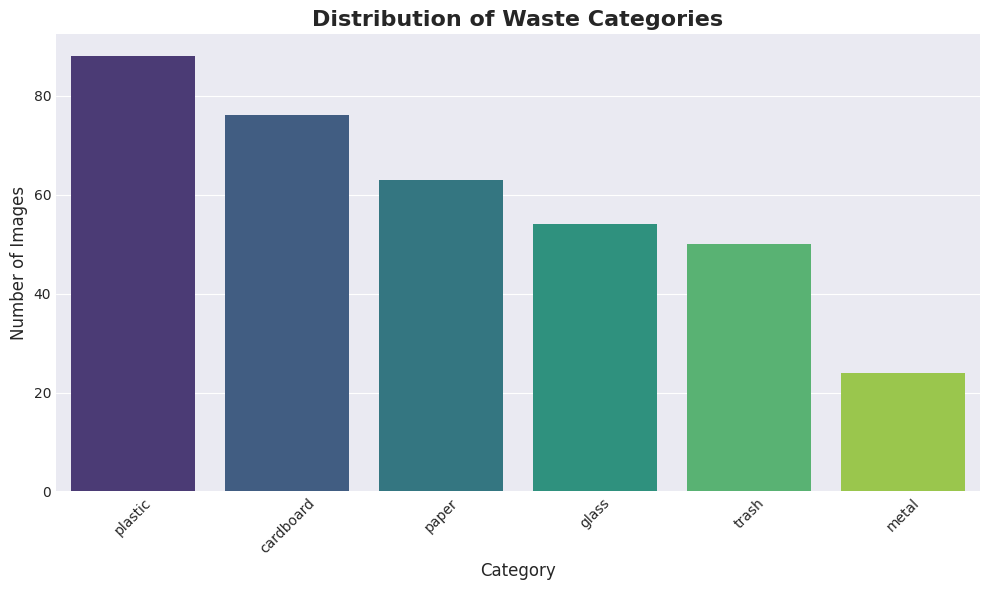


📊 Category Distribution:
category
plastic      88
cardboard    76
paper        63
glass        54
trash        50
metal        24
Name: count, dtype: int64


In [20]:
import seaborn as sns

# ✅ Safety check before plotting
if 'df' not in dir() or len(df) == 0:
    print("❌ df is empty or missing! Re-run Cell 2 first.")
else:
    plt.figure(figsize=(10, 6))
    category_counts = df['category'].value_counts()
    sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
    plt.title('Distribution of Waste Categories', fontsize=16, fontweight='bold')
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(f"\n📊 Category Distribution:")
    print(category_counts)


In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

# ✅ Correct path
data_dir = Path("../data/raw/Garbage Classification")

categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# ✅ Verify path exists
if not data_dir.exists():
    print(f"❌ Path not found: {data_dir.resolve()}")
    print(f"📍 Current working directory: {os.getcwd()}")
else:
    print(f"✅ Path found: {data_dir.resolve()}")

    # ✅ Auto-detect actual category folder names
    actual_folders = [f.name for f in data_dir.iterdir() if f.is_dir()]
    print(f"📂 Folders detected inside: {actual_folders}")

    image_data = []

    for category in actual_folders:
        cat_path = data_dir / category
        for ext in ["*.jpg", "*.jpeg", "*.png"]:
            for img_path in cat_path.glob(ext):
                image_data.append({
                    'path': str(img_path),
                    'category': category,
                    'filename': img_path.name
                })

    if len(image_data) == 0:
        print("❌ Still 0 images found! Check folder structure below:")
        for f in data_dir.rglob("*"):
            print(f"   {f}")
    else:
        df = pd.DataFrame(image_data)
        print(f"\n📊 Total images found: {len(df)}")
        print(f"📂 Categories found: {df['category'].nunique()}")
        print(f"\n🗂️ Images per category:")
        print(df['category'].value_counts())
        print(f"\n✅ df is ready! Columns: {df.columns.tolist()}")
        display(df.head())


✅ Path found: /workspaces/smart_recycling_classifier/data/raw/Garbage Classification
📂 Folders detected inside: ['cardboard', 'paper', 'plastic', 'metal', 'trash', 'glass']

📊 Total images found: 355
📂 Categories found: 6

🗂️ Images per category:
category
plastic      88
cardboard    76
paper        63
glass        54
trash        50
metal        24
Name: count, dtype: int64

✅ df is ready! Columns: ['path', 'category', 'filename']


,path,category,filename
0,../data/raw/Garbage Classification/cardboard/c...,cardboard,cardboard65.jpg
1,../data/raw/Garbage Classification/cardboard/c...,cardboard,cardboard390.jpg
2,../data/raw/Garbage Classification/cardboard/c...,cardboard,cardboard75.jpg
3,../data/raw/Garbage Classification/cardboard/c...,cardboard,cardboard60.jpg
4,../data/raw/Garbage Classification/cardboard/c...,cardboard,cardboard84.jpg


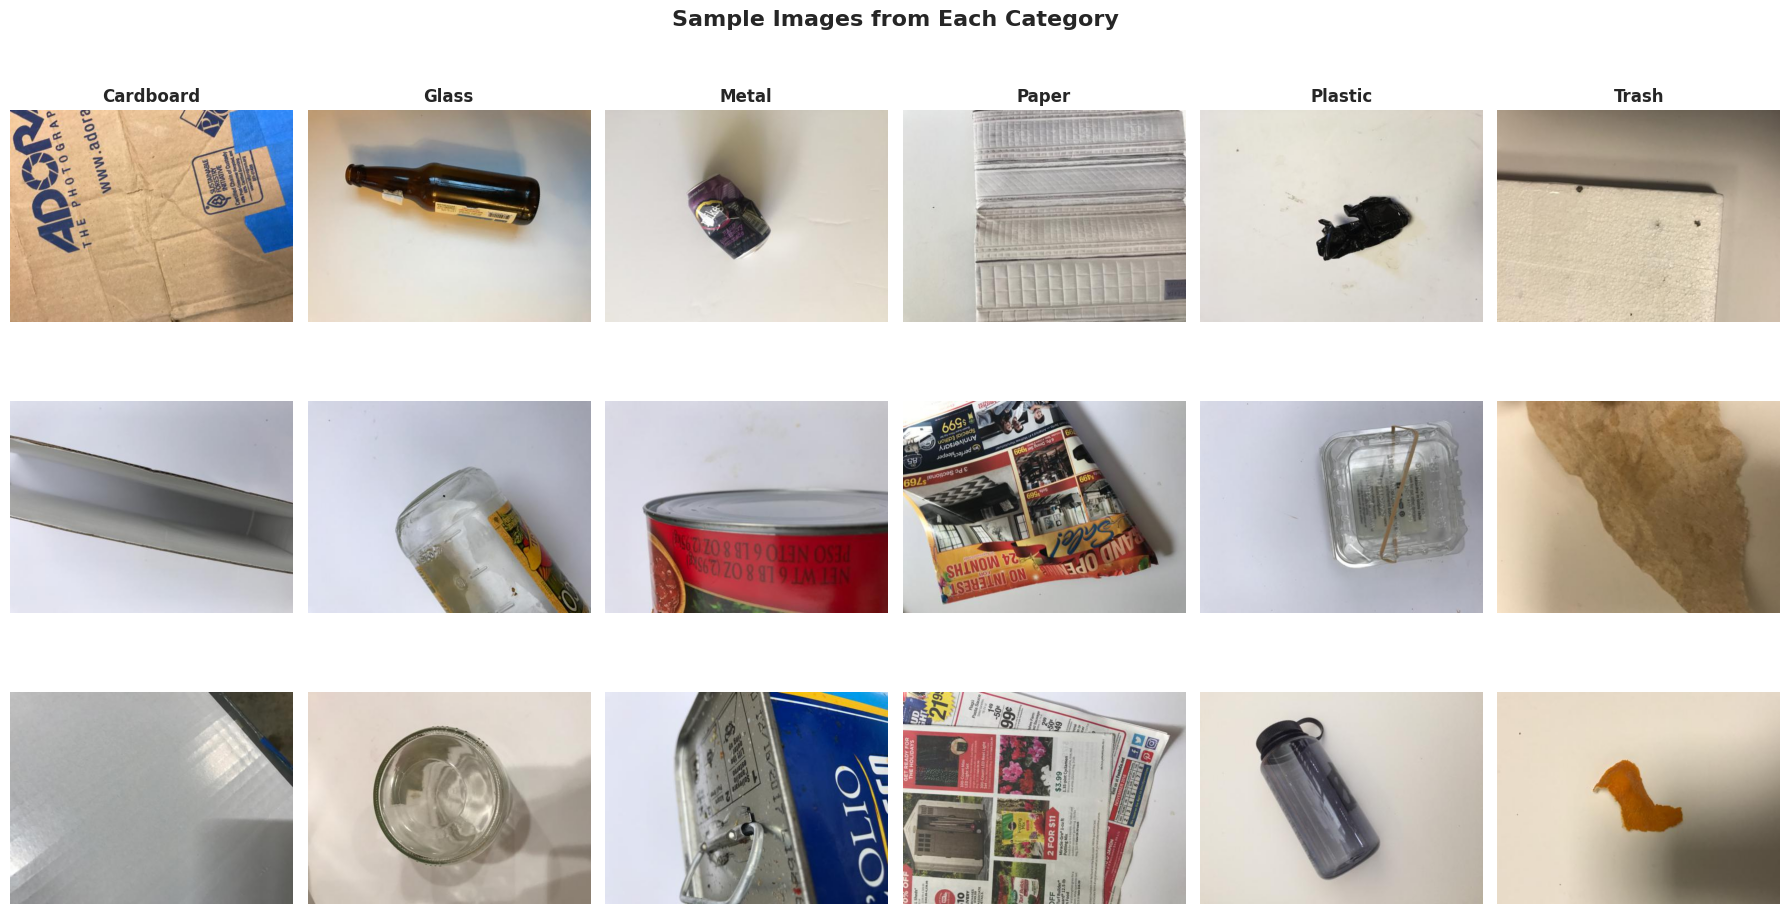

✅ Sample images displayed successfully!


In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ✅ Safety Check
if 'df' not in dir() or 'category' not in df.columns:
    print("❌ df is missing or has no 'category' column!")
    print("👉 Please re-run Cell 2 first.")
else:
    fig, axes = plt.subplots(3, len(categories), figsize=(18, 10))
    fig.suptitle('Sample Images from Each Category', fontsize=16, fontweight='bold')

    for idx, category in enumerate(categories):
        # Get samples from this category
        cat_df = df[df['category'] == category]

        # ✅ Safety: check enough images exist
        if len(cat_df) < 3:
            print(f"⚠️ Not enough images for category: {category} (found {len(cat_df)})")
            continue

        samples = cat_df.sample(3, random_state=42)

        for i, (_, row) in enumerate(samples.iterrows()):
            ax = axes[i, idx]
            try:
                img = mpimg.imread(row['path'])
                ax.imshow(img)
                ax.axis('off')
                if i == 0:
                    ax.set_title(category.capitalize(), fontsize=12, fontweight='bold')
            except Exception as e:
                ax.axis('off')
                ax.set_title(f"❌ Error\n{category}", fontsize=9)
                print(f"⚠️ Could not load image: {row['path']} — {e}")

    plt.tight_layout()
    plt.show()
    print("✅ Sample images displayed successfully!")


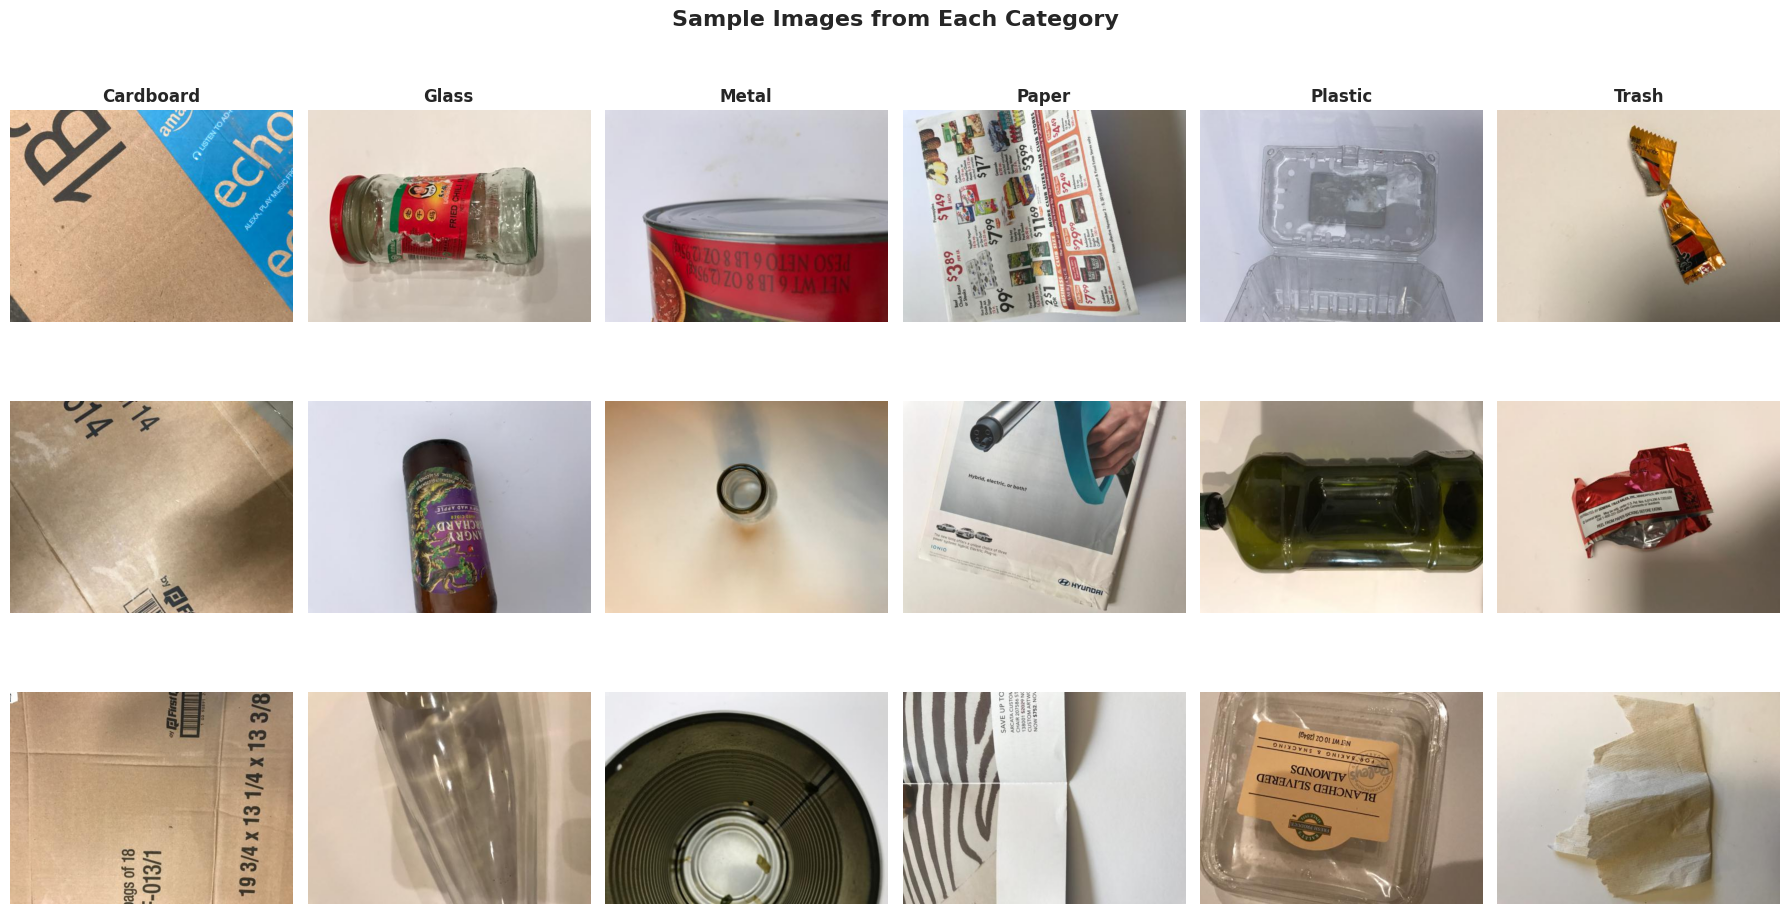

In [23]:
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
fig.suptitle('Sample Images from Each Category', fontsize=16, fontweight='bold')

for idx, category in enumerate(categories):
    # Get 3 random samples from each category
    samples = df[df['category'] == category].sample(3)
    
    for i, (_, row) in enumerate(samples.iterrows()):
        ax = axes[i, idx]
        img = Image.open(row['path'])
        ax.imshow(img)
        ax.axis('off')
        if i == 0:
            ax.set_title(category.capitalize(), fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

📐 Analyzing image dimensions...


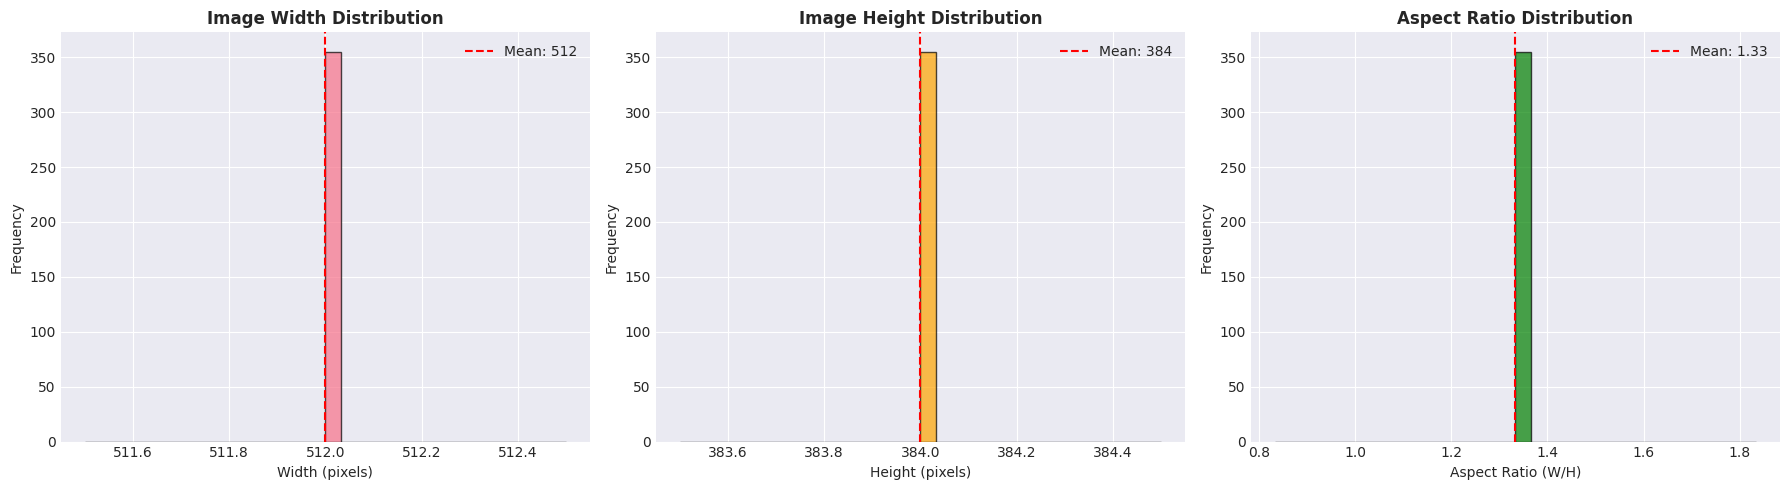


📊 Dimension Statistics:
       width  height  aspect_ratio
count  355.0   355.0  3.550000e+02
mean   512.0   384.0  1.333333e+00
std      0.0     0.0  2.223580e-16
min    512.0   384.0  1.333333e+00
25%    512.0   384.0  1.333333e+00
50%    512.0   384.0  1.333333e+00
75%    512.0   384.0  1.333333e+00
max    512.0   384.0  1.333333e+00


In [24]:
print("📐 Analyzing image dimensions...")

dimensions = []
for _, row in df.sample(min(500, len(df))).iterrows():  # Sample for speed
    try:
        img = Image.open(row['path'])
        dimensions.append({
            'width': img.width,
            'height': img.height,
            'aspect_ratio': img.width / img.height,
            'category': row['category']
        })
    except:
        continue

dim_df = pd.DataFrame(dimensions)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Width distribution
axes[0].hist(dim_df['width'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(dim_df['width'].mean(), color='red', linestyle='--', label=f'Mean: {dim_df["width"].mean():.0f}')
axes[0].legend()

# Height distribution
axes[1].hist(dim_df['height'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(dim_df['height'].mean(), color='red', linestyle='--', label=f'Mean: {dim_df["height"].mean():.0f}')
axes[1].legend()

# Aspect ratio
axes[2].hist(dim_df['aspect_ratio'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('Aspect Ratio Distribution', fontweight='bold')
axes[2].set_xlabel('Aspect Ratio (W/H)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(dim_df['aspect_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {dim_df["aspect_ratio"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('../results/plots/image_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Dimension Statistics:")
print(dim_df.describe())


In [25]:
from PIL import Image
import numpy as np

# ✅ Always redefine to avoid NameError
category_counts = df['category'].value_counts()

# ✅ Get image dimensions safely
dims = []
for _, row in df.iterrows():
    try:
        with Image.open(row['path']) as img:
            w, h = img.size
            dims.append({'width': w, 'height': h})
    except Exception as e:
        print(f"⚠️ Skipped: {row['path']} — {e}")

dim_df = pd.DataFrame(dims)

# ✅ Summary Stats
summary = {
    'Total Images'          : len(df),
    'Categories'            : df['category'].nunique(),
    'Avg Width'             : f"{dim_df['width'].mean():.0f} px",
    'Avg Height'            : f"{dim_df['height'].mean():.0f} px",
    'Most Common Category'  : category_counts.idxmax(),
    'Least Common Category' : category_counts.idxmin(),
    'Class Imbalance Ratio' : f"{category_counts.min() / category_counts.max():.2f}"
}

# ✅ Display nicely
print("=" * 40)
print("       📊 DATASET SUMMARY")
print("=" * 40)
for key, value in summary.items():
    print(f"  {key:<28}: {value}")
print("=" * 40)


       📊 DATASET SUMMARY
  Total Images                : 355
  Categories                  : 6
  Avg Width                   : 512 px
  Avg Height                  : 384 px
  Most Common Category        : plastic
  Least Common Category       : metal
  Class Imbalance Ratio       : 0.27


In [26]:
summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Value']
summary_df.to_csv('../results/reports/data_summary.csv')
print("\n✅ Summary saved to results/reports/data_summary.csv")


✅ Summary saved to results/reports/data_summary.csv
